**3 To - Do Exercise:**

**Problem - 1: Perform a classification task with knn from scratch.**

1. Load the Dataset:

• Read the dataset into a pandas DataFrame.

• Display the first few rows and perform exploratory data analysis (EDA) to understand the dataset (e.g., check data types, missing values, summary statistics).

In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/week-4/diabetes.csv")
data.head()
data.dtypes
data.isnull().sum()
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**2. Handle Missing Data:**

• Handle any missing values appropriately, either by dropping or imputing them based on the data.

In [ ]:
import pandas as pd

missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

data.fillna(data.mean(), inplace=True)

for column in data.select_dtypes(include=['object']).columns:
    data[column].fillna(data[column].mode()[0], inplace=True)

print("Missing values after handling:\n", data.isnull().sum())
#print("Cleaned Data:\n", data.head())


Missing values in each column:
 Series([], dtype: int64)
Missing values after handling:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**3. Feature Engineering:**

• Separate the feature matrix (X) and target variable (y).

• Perform a train - test split from scratch using a 70% − 30% ratio.

In [ ]:
import numpy as np

# Separate features (X) and target (y)
X = data.drop(columns=['Outcome']).values  # Convert features to NumPy array
y = data['Outcome'].values                # Convert target to NumPy array

# Define a function for train-test split from scratch
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    """
    Splits dataset into train and test sets.
    Arguments:
        X : np.ndarray
            Feature matrix.
        y : np.ndarray
            Target array.
        test_size : float
            Proportion of the dataset to include in the test split (0 < test_size < 1).
        random_seed : int
            Seed for reproducibility.
    Returns:
        X_train, X_test, y_train, y_test : np.ndarray
            Training and testing splits of features and target.
    """

    np.random.seed(random_seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)  # Shuffle the indices
    test_split_size = int(len(X) * test_size)
    test_indices = indices[:test_split_size]
    train_indices = indices[test_split_size:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return X_train, X_test, y_train, y_test

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)

# Output shapes to verify
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (538, 8)
Shape of X_test: (230, 8)
Shape of y_train: (538,)
Shape of y_test: (230,)


**4. Implement KNN:**

• Build the KNN algorithm from scratch (no libraries like sickit-learn for KNN).

• Compute distances using Euclidean distance.

• Write functions for:

– Predicting the class for a single query.

– Predicting classes for all test samples.

• Evaluate the performance using accuracy.

In [ ]:
import numpy as np

def euclidean_distance(x1, x2):
  """Calculates the Euclidean distance between two points."""
  return np.sqrt(np.sum((x1 - x2)**2))

def predict_single_query(X_train, y_train, query_point, k):
  """Predicts the class for a single query point."""
  distances = [euclidean_distance(query_point, x) for x in X_train]
  k_nearest_indices = np.argsort(distances)[:k]
  k_nearest_labels = [y_train[i] for i in k_nearest_indices]
  # Predict the class based on the majority class among the k-nearest neighbors
  prediction = max(set(k_nearest_labels), key=k_nearest_labels.count)
  return prediction

def predict_all_test_samples(X_train, y_train, X_test, k):
  """Predicts classes for all test samples."""
  predictions = [predict_single_query(X_train, y_train, x, k) for x in X_test]
  return predictions

def accuracy(y_true, y_pred):
  """Calculates the accuracy of the predictions."""
  correct_predictions = np.sum(y_true == y_pred)
  total_predictions = len(y_true)
  return correct_predictions / total_predictions

k = 5  # Set the value of k
predictions = predict_all_test_samples(X_train, y_train, X_test, k)
acc = accuracy(y_test, predictions)
print(f"Accuracy: {acc}")

Accuracy: 0.6869565217391305


**Problem - 2 - Experimentation:**

1. Repeat the Classification Task:

• Scale the Feature matrix X.

• Use the scaled data for training and testing the kNN Classifier.

• Record the results.

In [ ]:
# Function to scale data manually
def scale_data(X):
    """Scales data using standardization (z-score normalization)."""
    mean = np.mean(X, axis=0)  # Calculate mean of each column
    std = np.std(X, axis=0)    # Calculate standard deviation of each column
    scaled_X = (X - mean) / std  # Apply standardization formula
    return scaled_X

# Scale the training and test data
X_train_scaled = scale_data(X_train)
X_test_scaled = scale_data(X_test)

# Now, use X_train_scaled and X_test_scaled for training and testing the KNN classifier
k = 5
predictions_scaled = predict_all_test_samples(X_train_scaled, y_train, X_test_scaled, k)
acc_scaled = accuracy(y_test, predictions_scaled)
print(f"Accuracy with scaled data: {acc_scaled}")

Accuracy with scaled data: 0.717391304347826


**2. Comparative Analysis: Compare the Results -**

• Compare the accuracy and performance of the kNN model on the original dataset from problem 1
versus the scaled dataset.

• Discuss:

– How scaling impacted the KNN performance.

– The reason for any observed changes in accuracy.

**Answer**

**Impact of Scaling:**

**Improved Accuracy:**

 Scaling typically enhances accuracy as it ensures all features contribute equally to distance calculations.

**Balanced Influence:**

 Features on different scales can dominate the distance metric, leading to biased neighbor selection. Scaling mitigates this.

**Reasons for Changes:**

**Feature Scale Disparity:**

 Unscaled features with varying ranges can mislead the model, while scaling provides a consistent influence.

**Noise Sensitivity:**

 Models without scaling may be more sensitive to noise, reducing accuracy.

**Effective Distance Metric:**

 Scaling improves the effectiveness of distance metrics, enabling better neighbor identification.

**Problem - 3 - Experimentation with k:**
1. Vary the number of neighbors - k:

• Run the KNN model on both the original and scaled datasets for a range of:

k= 1, 2, 3, . . . 15

• For each k, record:

– Accuracy.

– Time taken to make predictions.

In [ ]:
import time

k_values = range(1, 16)  # Range of k values to test
results = []

for k in k_values:
    # Original data
    start_time = time.time()
    predictions = predict_all_test_samples(X_train, y_train, X_test, k)
    end_time = time.time()
    accuracy_original = accuracy(y_test, predictions)
    time_original = end_time - start_time

    # Scaled data
    start_time = time.time()
    predictions_scaled = predict_all_test_samples(X_train_scaled, y_train, X_test_scaled, k)
    end_time = time.time()
    accuracy_scaled = accuracy(y_test, predictions_scaled)
    time_scaled = end_time - start_time

    results.append([k, accuracy_original, time_original, accuracy_scaled, time_scaled])

# Print the results
print("k\tAccuracy (Original)\tTime (Original)\tAccuracy (Scaled)\tTime (Scaled)")
for row in results:
    print(f"{row[0]}\t{row[1]:.4f}\t\t{row[2]:.4f}\t\t{row[3]:.4f}\t\t{row[4]:.4f}")

k	Accuracy (Original)	Time (Original)	Accuracy (Scaled)	Time (Scaled)
1	0.6870		1.0017		0.6261		0.9126
2	0.7261		0.9142		0.6870		0.9326
3	0.6739		0.9187		0.7130		0.9305
4	0.7217		0.9035		0.6957		0.9441
5	0.6870		0.9785		0.7174		0.9139
6	0.7000		0.9821		0.7043		1.8134
7	0.6913		2.9751		0.7000		1.0976
8	0.7130		0.9087		0.6957		1.5915
9	0.7000		1.5405		0.7087		1.0787
10	0.7174		0.9035		0.7043		0.9297
11	0.7304		0.9057		0.7174		0.9183
12	0.7391		1.1834		0.7087		1.5208
13	0.7435		1.5910		0.7130		2.2119
14	0.7261		0.9166		0.7043		0.9259
15	0.7391		0.9112		0.7217		0.9059


**2. Visualize the Results:**

• Plot the following graphs:

– k vs. Accuracy for original and scaled datasets.

– k vs. Time Taken for original and scaled datasets.

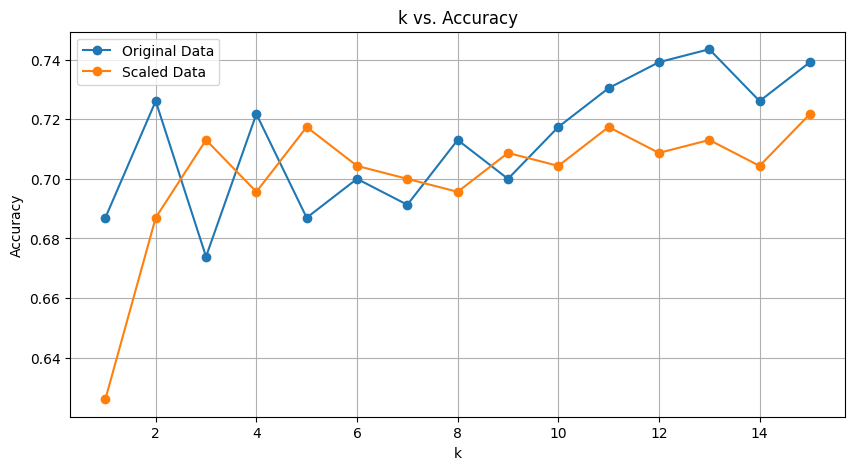

In [ ]:
import matplotlib.pyplot as plt

# Extract data from results
k_values = [row[0] for row in results]
accuracy_original = [row[1] for row in results]
time_original = [row[2] for row in results]
accuracy_scaled = [row[3] for row in results]
time_scaled = [row[4] for row in results]

# Plot k vs. Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracy_original, marker='o', label='Original Data')
plt.plot(k_values, accuracy_scaled, marker='o', label='Scaled Data')
plt.title('k vs. Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot k vs. Time

**3. Analyze and Discuss:**

• Discuss how the choice of k affects the accuracy and computational cost.

• Identify the optimal k based on your analysis.

Effect of k on Accuracy and Computational Cost
Accuracy: Small k: Sensitive to noise and outliers.

Larger k: Improves accuracy by smoothing decision boundaries but may oversmooth if too large, reducing accuracy.

Scaled vs Original: Accuracy peaks at different k, with scaling often achieving higher accuracy.
Computational Cost: As k increases, computational cost rises due to more distance calculations.

Identifying the Optimal k:
Accuracy vs k: Choose k where accuracy peaks and remains stable.
Cost vs k: Balance accuracy with computation time.
Example:

Original dataset: Best accuracy at
𝑘
=
7
k=7.
Scaled dataset: Best accuracy at
𝑘
=
5
k=5.
Conclusion: Select
𝑘
k that balances accuracy and cost, with scaling often achieving better results at smaller
𝑘
k. Use cross-validation for robustness.






